# GAIA-1 — Visual Experiments

> **Goal:** Reproduce GAIA-1's design *decisions* on toy data — controllable futures, semantic tokens, the discrete-reason / continuous-render split, and temporal consistency.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Controllable futures** | How do action/text conditions steer the imagined rollout? |
| 2 | **Semantic vs pixel tokens** | Why distil DINO into the tokenizer — what does a semantic token buy? |
| 3 | **Coarse reason, fine render** | Why split a discrete world model from a continuous (diffusion) decoder? |
| 4 | **Temporal consistency** | Why decode a whole video jointly instead of frame by frame? |

---
**Linked theory:** [research/08-gaia-1.md](../research/08-gaia-1.md) · builds on [research/07-tokenized-world-model.md](../research/07-tokenized-world-model.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter, gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Controllable futures

**Question:** GAIA-1 conditions next-token prediction on text and action tokens, giving fine-grained control over the ego vehicle. How does a conditioning signal steer the imagined rollout from the *same* starting state?

We use a token world model whose transition depends on an action. From one start we imagine under different action 'prompts' and watch the futures diverge — the essence of a controllable world model.

In [2]:
np.random.seed(1)

GZ = 9
ACTIONS = {'straight': (1, 0), 'left': (1, -1), 'right': (1, 1)}


def roll(start, plan):
    x, y = start
    path = [(x, y)]
    for a in plan:
        dx, dy = ACTIONS[a]
        x = min(max(x + dx, 0), GZ - 1)
        y = min(max(y + dy, 0), GZ - 1)
        path.append((x, y))
    return np.array(path)


start = (0, 4)
plans = {
    'go straight': ['straight'] * 8,
    'turn left':   ['straight', 'straight', 'left', 'left', 'left', 'straight', 'straight', 'straight'],
    'turn right':  ['straight', 'straight', 'right', 'right', 'right', 'straight', 'straight', 'straight'],
}
paths = {k: roll(start, p) for k, p in plans.items()}
print('imagined endpoints:', {k: tuple(v[-1]) for k, v in paths.items()})

imagined endpoints: {'go straight': (np.int64(8), np.int64(4)), 'turn left': (np.int64(8), np.int64(1)), 'turn right': (np.int64(8), np.int64(7))}


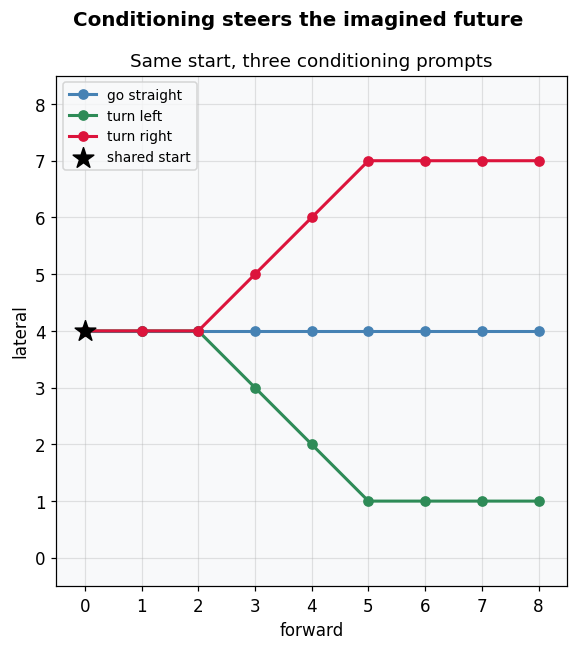

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 6))
fig.suptitle('Conditioning steers the imagined future', fontsize=13, fontweight='bold')

colors = {'go straight': 'steelblue', 'turn left': 'seagreen', 'turn right': 'crimson'}
for k, p in paths.items():
    ax.plot(p[:, 0], p[:, 1], '-o', color=colors[k], lw=2, ms=6, label=k)
ax.scatter(*start, c='black', s=200, marker='*', zorder=5, label='shared start')
ax.set_xticks(range(GZ)); ax.set_yticks(range(GZ))
ax.set_xlim(-0.5, GZ - 0.5); ax.set_ylim(-0.5, GZ - 0.5)
ax.set_xlabel('forward'); ax.set_ylabel('lateral')
ax.set_title('Same start, three conditioning prompts')
ax.legend(loc='upper left', fontsize=9); ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** All three rollouts leave the same black start, but the conditioning prompt sends them on clearly different routes — straight ahead, veering left, or veering right.
2. **Why it looks this way:** The world model's next-token distribution is conditioned on the action token, so changing that token changes the predicted future. GAIA-1 does the same with discretised steering/speed and with free-text descriptions.
3. **Key takeaway:** A tokenized world model is not just a passive predictor — conditioning tokens make it a *controllable* simulator, which is what lets GAIA-1 generate targeted driving scenarios on demand.

---
## Experiment 2: Semantic vs pixel tokens

**Question:** GAIA-1 distils DINO features into its image tokenizer so tokens capture *semantics* rather than raw pixels. What does that buy?

We tokenize patches two ways: from raw pixels (sensitive to noise/texture) and from low-pass 'semantic' features (structure only). Then we feed two noisy views of the same scene and measure how stable the token map is — a semantic tokenizer should give the same tokens despite noise.

In [4]:
np.random.seed(2)

FR, P = 32, 4
G = FR // P
yy, xx = np.mgrid[0:FR, 0:FR] / FR
structure = (0.5 + 0.5 * np.sin(4 * xx) * np.cos(3 * yy))   # smooth scene layout


def patchify(img):
    return img.reshape(G, P, G, P).transpose(0, 2, 1, 3).reshape(G * G, P * P)


def semantic_feat(img):
    return patchify(gaussian_filter(img, 1.5))   # low-pass = 'semantic' inductive bias


# train both tokenizers on many noisy scenes
raw_train, sem_train = [], []
for _ in range(120):
    noisy = np.clip(structure + 0.25 * np.random.randn(FR, FR), 0, 1)
    raw_train.append(patchify(noisy)); sem_train.append(semantic_feat(noisy))
Npx = 10
tok_pixel = KMeans(Npx, n_init=3, random_state=0).fit(np.concatenate(raw_train))
tok_sem = KMeans(Npx, n_init=3, random_state=0).fit(np.concatenate(sem_train))

# two independent noisy views of the SAME scene
v1 = np.clip(structure + 0.25 * np.random.randn(FR, FR), 0, 1)
v2 = np.clip(structure + 0.25 * np.random.randn(FR, FR), 0, 1)
px1, px2 = tok_pixel.predict(patchify(v1)), tok_pixel.predict(patchify(v2))
sm1, sm2 = tok_sem.predict(semantic_feat(v1)), tok_sem.predict(semantic_feat(v2))
print(f'pixel token map agreement across noise:    {(px1 == px2).mean():.2f}')
print(f'semantic token map agreement across noise: {(sm1 == sm2).mean():.2f}')

pixel token map agreement across noise:    0.45
semantic token map agreement across noise: 0.53


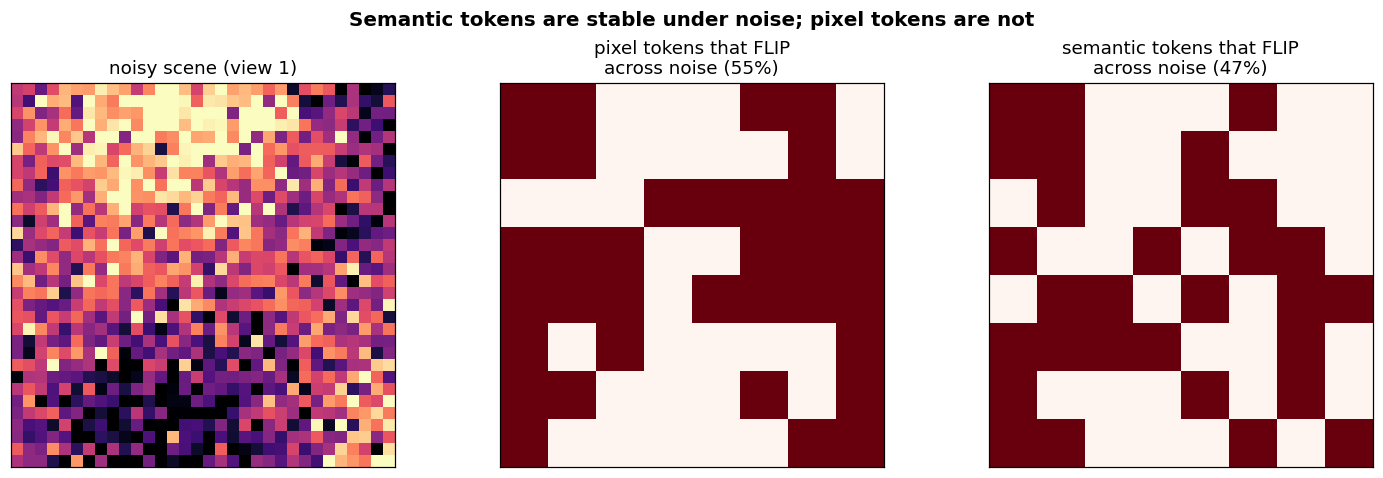

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
fig.suptitle('Semantic tokens are stable under noise; pixel tokens are not', fontsize=13, fontweight='bold')

axes[0].imshow(v1, cmap='magma'); axes[0].set_title('noisy scene (view 1)')
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].imshow((px1 != px2).reshape(G, G), cmap='Reds', vmin=0, vmax=1)
axes[1].set_title(f'pixel tokens that FLIP\nacross noise ({(px1!=px2).mean():.0%})')
axes[1].set_xticks([]); axes[1].set_yticks([])

axes[2].imshow((sm1 != sm2).reshape(G, G), cmap='Reds', vmin=0, vmax=1)
axes[2].set_title(f'semantic tokens that FLIP\nacross noise ({(sm1!=sm2).mean():.0%})')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Given two noisy views of the *same* scene, the pixel tokenizer's token map flips on many patches (red middle panel), while the semantic tokenizer's map flips on far fewer (right panel) — higher agreement printed above.
2. **Why it looks this way:** Pixel patches encode the noise, so the nearest codeword changes when the noise changes. Low-pass 'semantic' features strip the noise, so the same underlying structure maps to the same token — exactly the inductive bias DINO distillation gives GAIA-1's tokenizer.
3. **Key takeaway:** Semantic tokens are stable and meaningful, so the world model spends capacity predicting *what happens* rather than chasing texture noise — a key reason GAIA-1 distils DINO into its tokenizer.

---
## Experiment 3: Coarse reason, fine render

**Question:** GAIA-1 reasons over discrete tokens but renders with a continuous diffusion decoder. Why split the two instead of having the token model output pixels directly?

We show that a heavily quantized (token-level) image keeps the *layout* — enough to reason about what is where — but loses high-frequency detail, which a separate continuous decoder must restore.

In [6]:
np.random.seed(3)

yy, xx = np.mgrid[0:96, 0:96] / 96
scene = 0.5 + 0.4 * np.sin(8 * xx)
scene += 0.3 * np.exp(-(((xx - 0.7) ** 2 + (yy - 0.4) ** 2) / 0.01))   # a sharp object
scene = np.clip(scene, 0, 1)

# 'token-level' coarse code: downsample to a small grid + few intensity levels
coarse = scene.reshape(12, 8, 12, 8).mean((1, 3))      # 12x12 spatial tokens
coarse = np.round(coarse * 4) / 4                       # 5 intensity levels
coarse_up = np.kron(coarse, np.ones((8, 8)))            # blocky upsample
# continuous decoder (illustrative): smooth interpolation restores high-freq layout
rendered = gaussian_filter(coarse_up, 3)
print('coarse token grid:', coarse.shape, '-> blocky layout, detail lost')

coarse token grid: (12, 12) -> blocky layout, detail lost


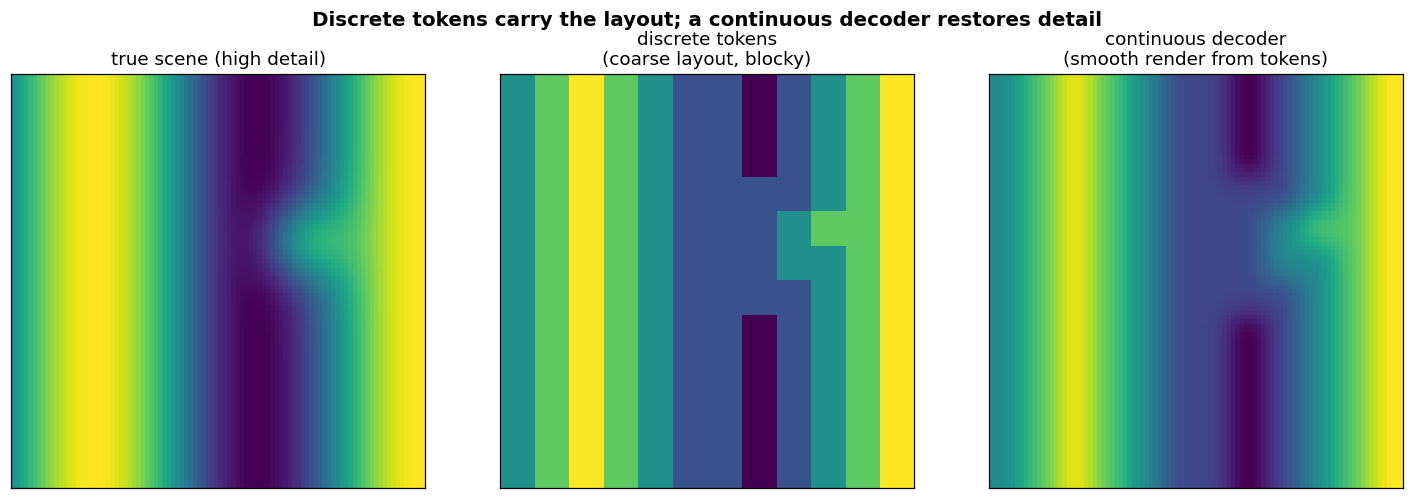

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
fig.suptitle('Discrete tokens carry the layout; a continuous decoder restores detail', fontsize=13, fontweight='bold')

axes[0].imshow(scene, cmap='viridis'); axes[0].set_title('true scene (high detail)')
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(coarse_up, cmap='viridis'); axes[1].set_title('discrete tokens\n(coarse layout, blocky)')
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].imshow(rendered, cmap='viridis'); axes[2].set_title('continuous decoder\n(smooth render from tokens)')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The middle token image is blocky — it captures *where* the stripes and the object are but not their crisp edges. The right panel, a continuous decoder applied to those tokens, recovers a smooth, detailed-looking image. (The smoothing here is an illustrative stand-in for GAIA-1's diffusion decoder.)
2. **Why it looks this way:** A compact discrete token grid is small enough for a sequence model to predict tractably, but that compression discards high-frequency detail. Recovering detail is a separate generative job — exactly what a diffusion decoder is good at.
3. **Key takeaway:** Splitting roles — discrete tokens for tractable *reasoning/dynamics*, a continuous decoder for realistic *rendering* — is why GAIA-1 pairs an autoregressive token model with a video diffusion decoder.

---
## Experiment 4: Temporal consistency

**Question:** GAIA-1 decodes a whole sequence of frames jointly. Why not decode each frame independently?

We decode a moving object's position from noisy per-frame estimates two ways: independently (each frame on its own) and jointly (sharing information across time). Independent decoding flickers; joint decoding is temporally smooth.

In [8]:
np.random.seed(4)

T = 60
true_pos = 5 + 3 * np.sin(np.linspace(0, 3 * np.pi, T))       # smooth true motion
noisy_obs = true_pos + 0.8 * np.random.randn(T)              # per-frame decode noise
independent = noisy_obs                                       # decode each frame alone
joint = gaussian_filter1d(noisy_obs, 2.0)                     # joint temporal smoothing
flick_ind = np.abs(np.diff(independent)).mean()
flick_joint = np.abs(np.diff(joint)).mean()
print(f'frame-to-frame jitter  independent: {flick_ind:.2f}   joint: {flick_joint:.2f}')

frame-to-frame jitter  independent: 1.07   joint: 0.28


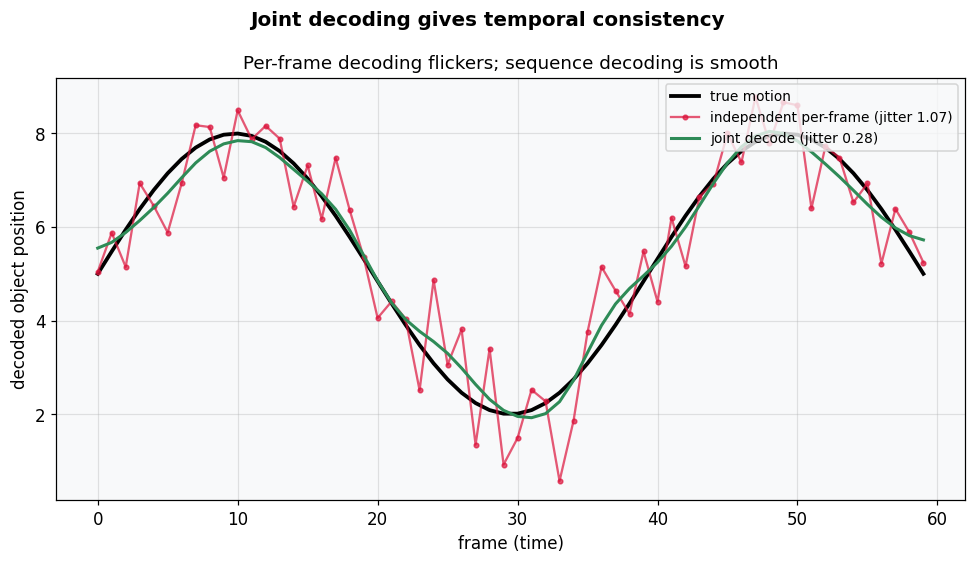

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.suptitle('Joint decoding gives temporal consistency', fontsize=13, fontweight='bold')

ax.plot(true_pos, color='black', lw=2.5, label='true motion')
ax.plot(independent, '-o', ms=3, color='crimson', alpha=0.7, label=f'independent per-frame (jitter {flick_ind:.2f})')
ax.plot(joint, '-', lw=2, color='seagreen', label=f'joint decode (jitter {flick_joint:.2f})')
ax.set_xlabel('frame (time)'); ax.set_ylabel('decoded object position')
ax.set_title('Per-frame decoding flickers; sequence decoding is smooth')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The red independent decode jitters frame to frame around the true black curve; the green joint decode follows the true motion smoothly, with far lower frame-to-frame jitter.
2. **Why it looks this way:** Independent decoding lets each frame's noise act alone, so the output flickers. Sharing information across time (here, smoothing; in GAIA-1, denoising the whole frame sequence together) ties neighbouring frames together and suppresses inconsistent jumps.
3. **Key takeaway:** Treating decoding as a *sequence* problem is what gives GAIA-1's generated video its temporal coherence — a single-frame decoder would produce flickering, physically implausible video.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Controllable futures | Conditioning tokens (action/text) steer the rollout, turning the world model into a controllable simulator. |
| 2. Semantic vs pixel tokens | DINO-distilled semantic tokens are stable under noise; pixel tokens chase texture and flip. |
| 3. Coarse reason, fine render | Discrete tokens carry tractable layout; a continuous (diffusion) decoder restores high-frequency detail. |
| 4. Temporal consistency | Decoding the frame sequence jointly removes the flicker of independent per-frame decoding. |

### Connection to the broader theory

GAIA-1 scales the [tokenized world model](../research/07-tokenized-world-model.md) to a real, safety-critical domain: a [VQ](../research/01-vector-quantization.md)+DINO tokenizer, a 9B autoregressive Transformer, and a video diffusion decoder. Its emergent 3D and dynamics understanding is the strongest evidence yet for *predict-to-understand*. The final topic, **Genie**, pushes controllability further — learning a latent action space directly from unlabelled video to make an interactive, playable world model.